![lop](../../images/logo_diive1_128px.png)

<span style='font-size:40px; display:block;'>
<b>
    Long-term random forest gap-filling
</b>
</span>

---
**Notebook version**: `2` (12 Jan 2026)  
**Author**: Lukas Hörtnagl (holukas@ethz.ch)  

</br>

# **Background**

- This notebook uses `diive`'s long-term random forest class `LongTermGapFillingRandomForestTS`to gap-fill time series data
- The `long-term` approach involves constructing annual random forest models, where each model is trained using data from the target year and its immediate two neighboring years.

</br>

# **User settings**
`TARGET_COL` ... name of the time series that is gap-filled  
`subsetcols` ... list of columns included in the random forest model, target must also be listed here

All columns that are not the target will be used as features/predictors during model building.

In [1]:
TARGET_COL = 'NEE_CUT_REF_orig'
subsetcols = [TARGET_COL, 'Tair_f', 'VPD_f', 'Rg_f']

</br>

# **Imports**
- This notebook uses `diive` ([source code](https://gitlab.ethz.ch/diive/diive)) to check eddy covariance fluxes for quality

In [2]:
import numpy as np
import importlib.metadata
from datetime import datetime
import matplotlib.pyplot as plt
from diive.configs.exampledata import load_exampledata_parquet
from diive.core.plotting.timeseries import TimeSeries  # For simple (interactive) time series plotting
from diive.core.dfun.stats import sstats  # Time series stats
from diive.core.plotting.heatmap_datetime import HeatmapDateTime
from diive.pkgs.gapfilling.longterm import LongTermGapFillingRandomForestTS
import warnings
warnings.filterwarnings('ignore')
version_diive = importlib.metadata.version("diive")
print(f"diive version: v{version_diive}")

diive version: v0.90.0


</br>

# **Docstring** for `RandomForestTS`

In [3]:
# help(LongTermGapFillingRandomForestTS)

</br>

---

# **Load data**

## Load example data from parquet file

In [4]:
source_df = load_exampledata_parquet()

Loaded .parquet file F:\Sync\luhk_work\20 - CODING\21 - DIIVE\diive\diive\configs\exampledata\exampledata_PARQUET_CH-DAV_FP2022.5_2013-2022_ID20230206154316_30MIN.parquet (0.174 seconds).
    --> Detected time resolution of <30 * Minutes> / 30min 


## Make subset

In [5]:
df = source_df.copy()
lowquality = df["QCF_NEE"] > 0  # This example uses NEE flux data, only records where the quality flag QCF is 0 (highest quality) are retained
df.loc[lowquality, TARGET_COL] = np.nan  # Set fluxes of lower quality to missing
df = df[subsetcols].copy()  # Keep subset columns only

In [6]:
df.describe()

,NEE_CUT_REF_orig,Tair_f,VPD_f,Rg_f
count,41284.000000,175296.000000,175296.000000,175296.000000
mean,-3.833522,4.712999,3.233176,152.671445
std,6.085449,7.548653,3.710180,247.531312
min,-38.653000,-23.096000,0.000000,0.000000
25%,-7.840000,-0.800000,0.661000,0.000000
50%,-3.827000,4.600000,1.991000,2.596000
75%,0.606250,10.067000,4.375000,225.677750
max,25.290000,28.713000,32.118000,1197.800000


In [7]:
sstats(df[TARGET_COL])

,NEE_CUT_REF_orig
STARTDATE,2013-01-01 00:15
ENDDATE,2022-12-31 23:45
PERIOD,3651 days 23:30:00
NOV,41284
MISSING,134012
MISSING_PERC,76.448978
MEAN,-3.833522
MEDIAN,-3.827
SD,6.085449
VAR,37.032694


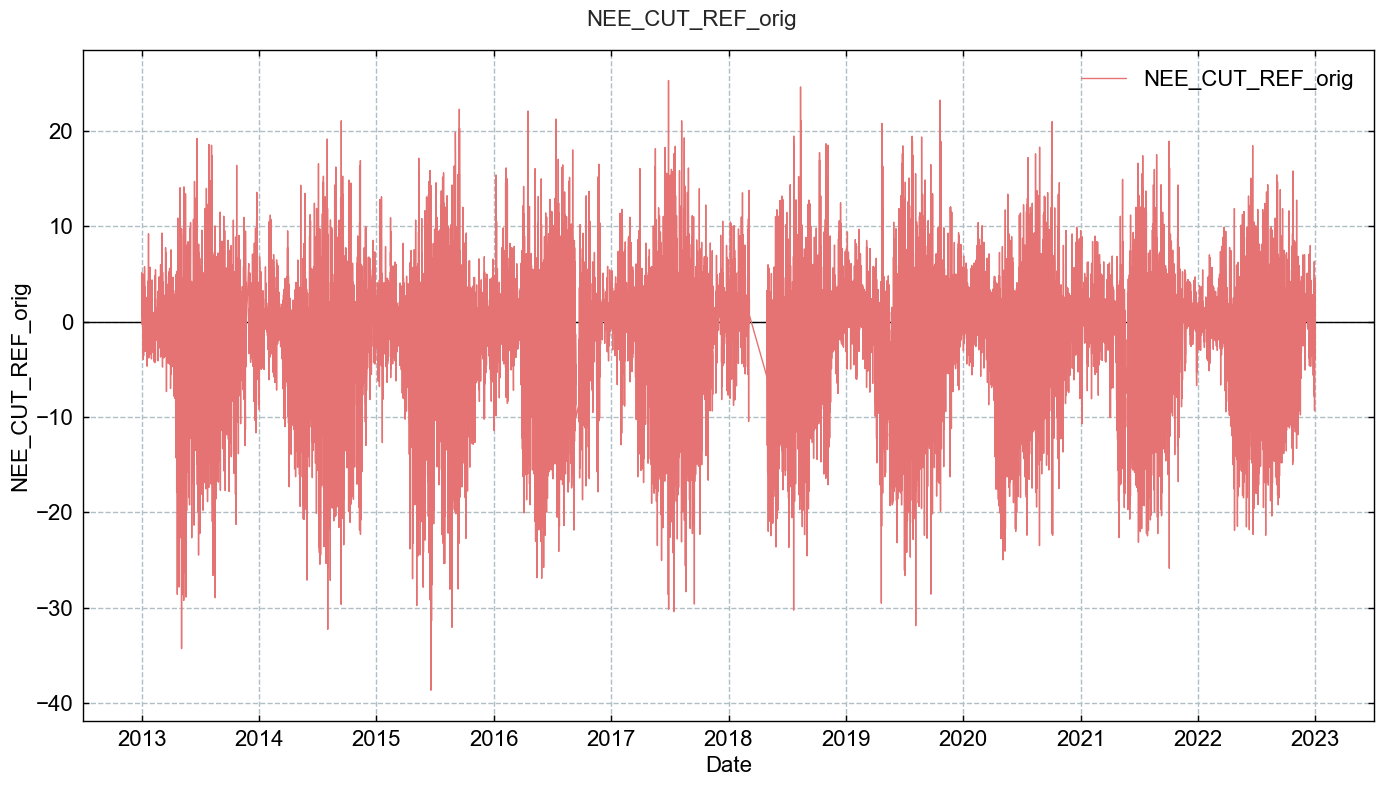

In [8]:
# TimeSeries(series=df[TARGET_COL]).plot_interactive()
TimeSeries(series=df[TARGET_COL]).plot()

</br>

</br>

# **Gap-filling**

## Initialize random forest

In [9]:
gf = LongTermGapFillingRandomForestTS(
        input_df=df,
        target_col=TARGET_COL,
        verbose=2,
        features_lag=[-1, -1],
        features_lag_exclude_cols=None,
        features_lag_stepsize=1,
        features_rolling=None,
        features_rolling_exclude_cols=None,
        features_rolling_stats=None,
        features_diff=None,
        features_diff_exclude_cols=None,
    features_ema=[6, 24, 48],
    features_ema_exclude_cols=None,
        features_poly_degree=None,
        features_poly_exclude_cols=None,
        vectorize_timestamps=False,
        add_continuous_record_number=False,        
        sanitize_timestamp=False,
        n_estimators=3,
        random_state=42,
        min_samples_split=2,
        min_samples_leaf=1,
        n_jobs=-1
    )



Starting gap-filling for
NEE_CUT_REF_orig
using <class 'sklearn.ensemble._forest.RandomForestRegressor'>

Adding new data columns ...
++ Added new columns with lagged variants for: ['Tair_f', 'VPD_f', 'Rg_f'] (lags between -1 and -1 with stepsize 1), no lagged variants for: ['NEE_CUT_REF_orig']. Shifting the time series created gaps which were then filled with the nearest value.
++ Added new columns with timestamp info: ['.YEAR', '.SEASON', '.SEASON_SIN', '.SEASON_COS', '.MONTH', '.MONTH_SIN', '.MONTH_COS', '.WEEK', '.WEEK_SIN', '.WEEK_COS', '.DOY', '.DOY_SIN', '.DOY_COS', '.HOUR', '.HOUR_SIN', '.HOUR_COS', '.YEARMONTH', '.YEARDOY', '.YEARWEEK'] 
++ Added new column .RECORDNUMBER with record numbers from 1 to 175296.

Sanitizing timestamp ...
>>> Validating timestamp naming of timestamp column TIMESTAMP_MIDDLE ... Timestamp name OK.
>>> Converting timestamp TIMESTAMP_MIDDLE to datetime ... OK
>>> All rows have timestamp TIMESTAMP_MIDDLE, no rows removed.
>>> Sorting timestamp TIMESTA

</br>

## Assign yearpools

In [10]:
gf.create_yearpools()
gf.initialize_yearly_models()

[neighboring_years] Assigned [2013, 2014, 2015] to data pool for 2013.
[neighboring_years] Assigned [2013, 2014, 2015] to data pool for 2014.
[neighboring_years] Assigned [2014, 2015, 2016] to data pool for 2015.
[neighboring_years] Assigned [2015, 2016, 2017] to data pool for 2016.
[neighboring_years] Assigned [2016, 2017, 2018] to data pool for 2017.
[neighboring_years] Assigned [2017, 2018, 2019] to data pool for 2018.
[neighboring_years] Assigned [2018, 2019, 2020] to data pool for 2019.
[neighboring_years] Assigned [2019, 2020, 2021] to data pool for 2020.
[neighboring_years] Assigned [2020, 2021, 2022] to data pool for 2021.
[neighboring_years] Assigned [2020, 2021, 2022] to data pool for 2022.
Initializing model for 2013 ...


Starting gap-filling for
NEE_CUT_REF_orig
using <class 'sklearn.ensemble._forest.RandomForestRegressor'>
Initializing model for 2014 ...


Starting gap-filling for
NEE_CUT_REF_orig
using <class 'sklearn.ensemble._forest.RandomForestRegressor'>
Initializing

</br>

## Feature reduction

In [11]:
gf.reduce_features_across_years()

---
Reducing features based on permutation importance for year 2013 ...

[ FEATURE REDUCTION ] Feature reduction based on permutation importance ...
[ FEATURE REDUCTION ] >>> Calculating feature importances (permutation importance, 9 repeats) ...
[ FEATURE REDUCTION ] >>> Setting threshold for feature rejection to 0.04038159357200746.

[ FEATURE REDUCTION ] >>> Accepted features and their importance:
               PERM_IMPORTANCE
Rg_f                  1.275569
.DOY_COS              0.367640
.HOUR_SIN             0.149078
.VPD_f-1              0.125397
.RECORDNUMBER         0.115969
.Tair_f-1             0.109817
VPD_f                 0.091996
.DOY_SIN              0.077258
Tair_f                0.076701
.Rg_f-1               0.070698

[ FEATURE REDUCTION ] >>> Rejected features and their importance:
             PERM_IMPORTANCE
.HOUR_COS           0.030499
.YEARDOY            0.028846
.WEEK_SIN           0.023226
.YEARWEEK           0.009385
.WEEK_COS           0.007574
.YEARMONTH    

</br>

## Fill gaps

In [12]:
gf.fillgaps()


Training model for 2013 ...

Training final model ...
>>> Training model <class 'sklearn.ensemble._forest.RandomForestRegressor'> based on data between 2013-01-01 06:15:00 and 2015-12-31 09:15:00 ...
>>> Fitting model to training data ...
>>> Using model to predict target NEE_CUT_REF_orig in unseen test data ...
>>> Using model to calculate permutation importance based on unseen test data ...
>>> Calculating prediction scores based on predicting unseen test data of NEE_CUT_REF_orig ...
>>> Collecting results, details about training and testing can be accessed by calling .report_traintest().
>>> Done.

Gap-filling 2013 ...

Gap-filling using final model ...
>>> Using final model on all data to predict target NEE_CUT_REF_orig ...
>>> Using final model on all data to calculate permutation importance ...
>>> Calculating prediction scores based on all data predicting NEE_CUT_REF_orig ...
>>> Predicting target NEE_CUT_REF_orig where all features are available ... predicted 52560 records.
>>

</br>

## Results
A lot more information about feature reduction, training and testing, model building and gap-filling is available via the class attributes.

### Dataframe with gap-filled time series

In [13]:
gf.gapfilling_df_

,.PREDICTIONS_FULLMODEL,NEE_CUT_REF_orig,.GAP_PREDICTIONS,FLAG_NEE_CUT_REF_orig_gfRF_ISFILLED,NEE_CUT_REF_orig_gfRF,.PREDICTIONS_FALLBACK,.GAPFILLED_CUMULATIVE,.PREDICTIONS
TIMESTAMP_MIDDLE,,,,,,,,
2013-01-01 00:15:00,1.478505,NaN,1.478505,1,1.478505,None,1.478505,1.478505
2013-01-01 00:45:00,1.463505,NaN,1.463505,1,1.463505,None,2.942010,1.463505
2013-01-01 01:15:00,1.340091,NaN,1.340091,1,1.340091,None,4.282101,1.340091
2013-01-01 01:45:00,1.375091,0.538,NaN,0,0.538000,None,4.820101,1.375091
2013-01-01 02:15:00,1.095535,NaN,1.095535,1,1.095535,None,5.915636,1.095535
...,...,...,...,...,...,...,...,...
2022-12-31 21:45:00,0.800343,NaN,0.800343,1,0.800343,None,-9164.612313,0.800343
2022-12-31 22:15:00,-0.092495,3.518,NaN,0,3.518000,None,-9161.094313,-0.092495
2022-12-31 22:45:00,1.313515,NaN,1.313515,1,1.313515,None,-9159.780798,1.313515


### Gap-filled variable

In [14]:
print(f"The variable name of the gap-filled time series is {gf.gapfilled_.name}.")
gf.gapfilled_

The variable name of the gap-filled time series is NEE_CUT_REF_orig_gfRF.


TIMESTAMP_MIDDLE
2013-01-01 00:15:00    1.478505
2013-01-01 00:45:00    1.463505
2013-01-01 01:15:00    1.340091
2013-01-01 01:45:00    0.538000
2013-01-01 02:15:00    1.095535
                         ...   
2022-12-31 21:45:00    0.800343
2022-12-31 22:15:00    3.518000
2022-12-31 22:45:00    1.313515
2022-12-31 23:15:00    1.409667
2022-12-31 23:45:00    2.069586
Freq: 30min, Name: NEE_CUT_REF_orig_gfRF, Length: 175296, dtype: float64

### Yearly data pools

In [15]:
gf.yearpools

{'2013': {'poolyears': [2013, 2014, 2015],
  'df':                      .DOY_COS  .DOY_SIN  .HOUR_COS  .HOUR_SIN  .RECORDNUMBER  .Rg_f-1  ...  .WEEK_COS     .WEEK_SIN  Rg_f  Tair_f  VPD_f  NEE_CUT_REF_orig
  TIMESTAMP_MIDDLE                                                                       ...                                                                
  2013-01-01 00:15:00  0.999852  0.017202   1.000000   0.000000              1      0.0  ...   0.992981  1.182732e-01   0.0  -1.618  1.339               NaN
  2013-01-01 00:45:00  0.999852  0.017202   1.000000   0.000000              2      0.0  ...   0.992981  1.182732e-01   0.0  -1.630  1.337               NaN
  2013-01-01 01:15:00  0.999852  0.017202   0.965926   0.258819              3      0.0  ...   0.992981  1.182732e-01   0.0  -1.644  1.335               NaN
  2013-01-01 01:45:00  0.999852  0.017202   0.965926   0.258819              4      0.0  ...   0.992981  1.182732e-01   0.0  -1.657  1.332             0.538
  2013-01

### Dictionary of yearly model instances

In [16]:
gf.results_yearly_

{'2013': <diive.core.ml.common.MlRegressorGapFillingBase at 0x19b137924d0>,
 '2014': <diive.core.ml.common.MlRegressorGapFillingBase at 0x19b1356b310>,
 '2015': <diive.core.ml.common.MlRegressorGapFillingBase at 0x19b12e04e90>,
 '2016': <diive.core.ml.common.MlRegressorGapFillingBase at 0x19b12d96950>,
 '2017': <diive.core.ml.common.MlRegressorGapFillingBase at 0x19b1378b610>,
 '2018': <diive.core.ml.common.MlRegressorGapFillingBase at 0x19b13715a90>,
 '2019': <diive.core.ml.common.MlRegressorGapFillingBase at 0x19b137178d0>,
 '2020': <diive.core.ml.common.MlRegressorGapFillingBase at 0x19b137dae50>,
 '2021': <diive.core.ml.common.MlRegressorGapFillingBase at 0x19b136f8350>,
 '2022': <diive.core.ml.common.MlRegressorGapFillingBase at 0x19b1376bd90>}

### Test scores per year

In [17]:
gf.scores_

{'2013': {'mae': 1.2696489051056208,
  'medae': np.float64(0.7874444444444371),
  'mse': 4.009958894717354,
  'rmse': 2.002488175924481,
  'mape': 1070325104611.5618,
  'maxe': np.float64(23.98078787878788),
  'r2': 0.8991002830302627},
 '2014': {'mae': 1.2696489051056206,
  'medae': np.float64(0.7874444444444362),
  'mse': 4.009958894717354,
  'rmse': 2.002488175924481,
  'mape': 1070325104611.5621,
  'maxe': np.float64(23.98078787878788),
  'r2': 0.8991002830302628},
 '2015': {'mae': 1.2470637625230563,
  'medae': np.float64(0.7756919191919185),
  'mse': 3.872602799590559,
  'rmse': 1.9678929847912359,
  'mape': 0.8450345398312832,
  'maxe': np.float64(27.020969696969697),
  'r2': 0.902964849413831},
 '2016': {'mae': 1.2280634514045816,
  'medae': np.float64(0.7846363636363674),
  'mse': 3.6899514447728183,
  'rmse': 1.9209246327674645,
  'mape': 789074413637.7567,
  'maxe': np.float64(25.33165656565656),
  'r2': 0.9073163382662366},
 '2017': {'mae': 1.1843294288313908,
  'medae': np

In [18]:
from statistics import mean
scores = []
r2s = []
print("SCORES PER YEAR")
for year, s in gf.scores_.items():
    print(f"{year}: r2 = {s['r2']}  MAE = {s['mae']}")
    scores.append(s['mae'])
    r2s.append(s['r2'])
print(f"{'-' * 20}\nMEAN MAE: {mean(scores)}\nMEAN r2: {mean(r2s)}")

SCORES PER YEAR
2013: r2 = 0.8991002830302627  MAE = 1.2696489051056208
2014: r2 = 0.8991002830302628  MAE = 1.2696489051056206
2015: r2 = 0.902964849413831  MAE = 1.2470637625230563
2016: r2 = 0.9073163382662366  MAE = 1.2280634514045816
2017: r2 = 0.9132347659789336  MAE = 1.1843294288313908
2018: r2 = 0.9163443754181105  MAE = 1.1699731330645196
2019: r2 = 0.9230756878729487  MAE = 1.0923495810884387
2020: r2 = 0.9181608491559073  MAE = 1.0659321723611341
2021: r2 = 0.9215796155976561  MAE = 1.0143738196661876
2022: r2 = 0.9215796155976561  MAE = 1.0143738196661876
--------------------
MEAN MAE: 1.1555756978816738
MEAN r2: 0.9122456663361805


### Feature importances per year

In [19]:
gf.feature_importances_yearly_

{'2013':                PERM_IMPORTANCE   PERM_SD
 Rg_f                  1.249359  0.019612
 .DOY_COS              0.363999  0.006694
 .RECORDNUMBER         0.159621  0.002169
 .HOUR_SIN             0.130683  0.003614
 .VPD_f-1              0.113778  0.002065
 .Tair_f-1             0.108075  0.001521
 VPD_f                 0.088867  0.001643
 .DOY_SIN              0.073719  0.002039
 Tair_f                0.070898  0.001174
 .Rg_f-1               0.066392  0.001470
 .HOUR_COS             0.024626  0.001023
 .WEEK_SIN             0.023214  0.000607
 .WEEK_COS             0.007056  0.000284,
 '2014':                PERM_IMPORTANCE   PERM_SD
 Rg_f                  1.249359  0.019612
 .DOY_COS              0.363999  0.006694
 .RECORDNUMBER         0.159621  0.002169
 .HOUR_SIN             0.130683  0.003614
 .VPD_f-1              0.113778  0.002065
 .Tair_f-1             0.108075  0.001521
 VPD_f                 0.088867  0.001643
 .DOY_SIN              0.073719  0.002039
 Tair_f          

### Features used in all models, after reduction

In [20]:
gf.features_reduced_across_years

['.DOY_COS',
 '.DOY_SIN',
 '.HOUR_COS',
 '.HOUR_SIN',
 '.RECORDNUMBER',
 '.Rg_f-1',
 '.Tair_f-1',
 '.VPD_f-1',
 '.WEEK_COS',
 '.WEEK_SIN',
 'Rg_f',
 'Tair_f',
 'VPD_f']

### Feature ranks per year

In [21]:
gf.feature_ranks_per_year

YEAR,2013,2014,2015,2016,2017,2018,2019,2020,2021,2022
FEATURE,,,,,,,,,,
Rg_f,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0
.DOY_COS,2.0,2.0,2.0,2.0,8.0,2.0,2.0,2.0,6.0,6.0
.RECORDNUMBER,3.0,3.0,4.0,4.0,5.0,9.0,7.0,5.0,9.0,9.0
.HOUR_SIN,4.0,4.0,5.0,6.0,7.0,6.0,6.0,7.0,7.0,7.0
.VPD_f-1,5.0,5.0,8.0,8.0,6.0,7.0,8.0,9.0,10.0,10.0
.Tair_f-1,6.0,6.0,3.0,3.0,4.0,3.0,3.0,3.0,2.0,2.0
VPD_f,7.0,7.0,9.0,9.0,11.0,10.0,9.0,10.0,11.0,11.0
.DOY_SIN,8.0,8.0,7.0,11.0,10.0,5.0,10.0,6.0,8.0,8.0
Tair_f,9.0,9.0,10.0,5.0,3.0,4.0,4.0,4.0,3.0,3.0


### Feature importance per year

In [22]:
gf.feature_importance_per_year

YEAR,2013,2014,2015,2016,2017,2018,2019,2020,2021,2022
FEATURE,,,,,,,,,,
Rg_f,1.249359,1.249359,1.097472,0.998349,1.091137,1.154213,1.191179,1.266421,1.252484,1.252484
.DOY_COS,0.363999,0.363999,0.337775,0.370365,0.064906,0.397483,0.320292,0.360966,0.113289,0.113289
.RECORDNUMBER,0.159621,0.159621,0.120322,0.111377,0.094900,0.076320,0.089691,0.115474,0.076650,0.076650
.HOUR_SIN,0.130683,0.130683,0.110316,0.099387,0.088182,0.095156,0.095348,0.098100,0.107208,0.107208
.VPD_f-1,0.113778,0.113778,0.087278,0.077313,0.093914,0.094250,0.076063,0.054547,0.049532,0.049532
.Tair_f-1,0.108075,0.108075,0.132890,0.166806,0.147391,0.203404,0.179588,0.247213,0.160648,0.160648
VPD_f,0.088867,0.088867,0.074818,0.057582,0.049241,0.048941,0.063886,0.045582,0.049158,0.049158
.DOY_SIN,0.073719,0.073719,0.087568,0.049021,0.062927,0.101955,0.054988,0.105850,0.097608,0.097608
Tair_f,0.070898,0.070898,0.069670,0.105217,0.147630,0.122145,0.149075,0.163834,0.147976,0.147976


### Plot: feature ranks per year

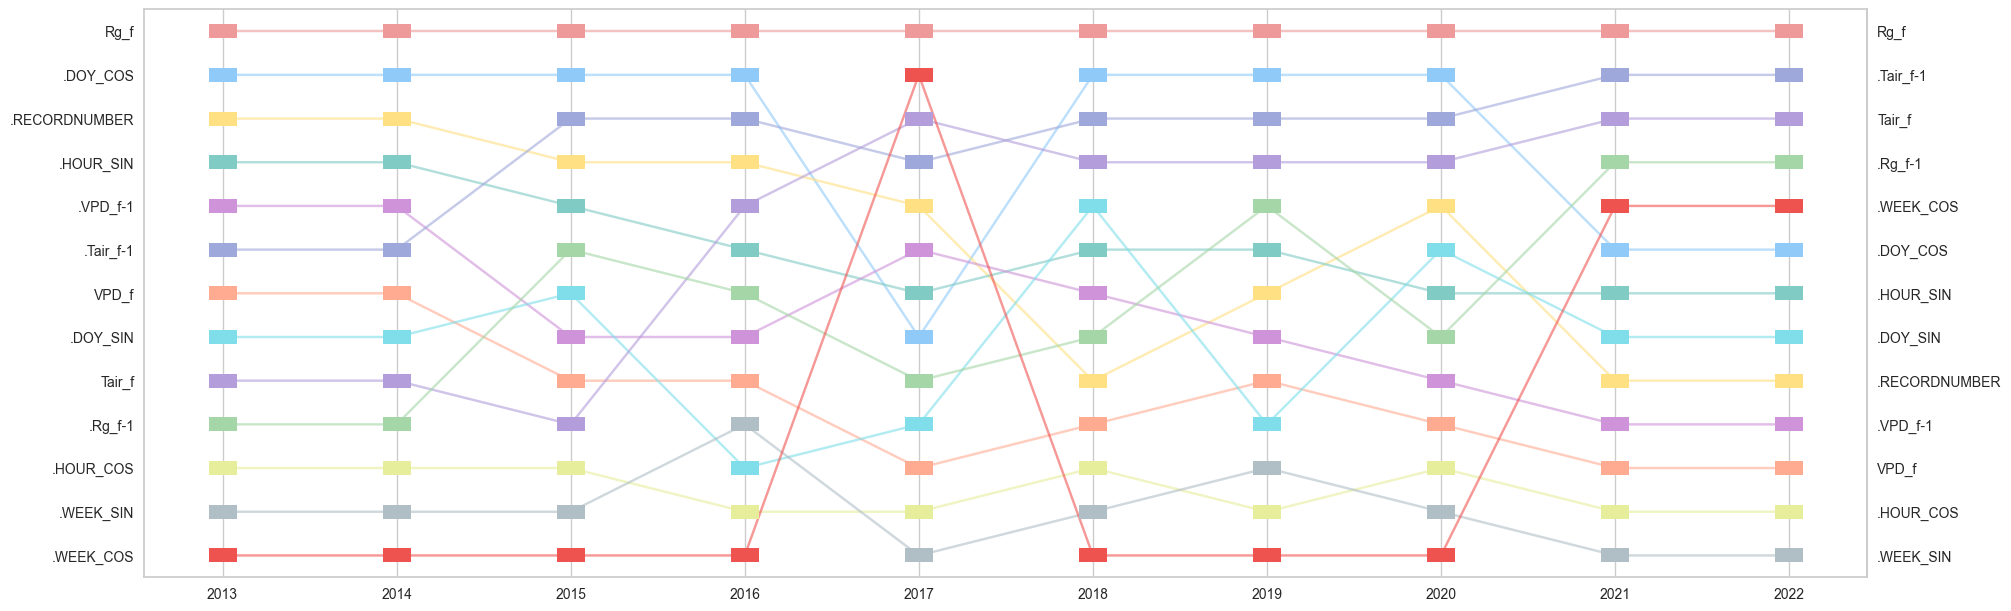

In [23]:
gf.showplot_feature_ranks_per_year()

</br>

</br>

## Plot

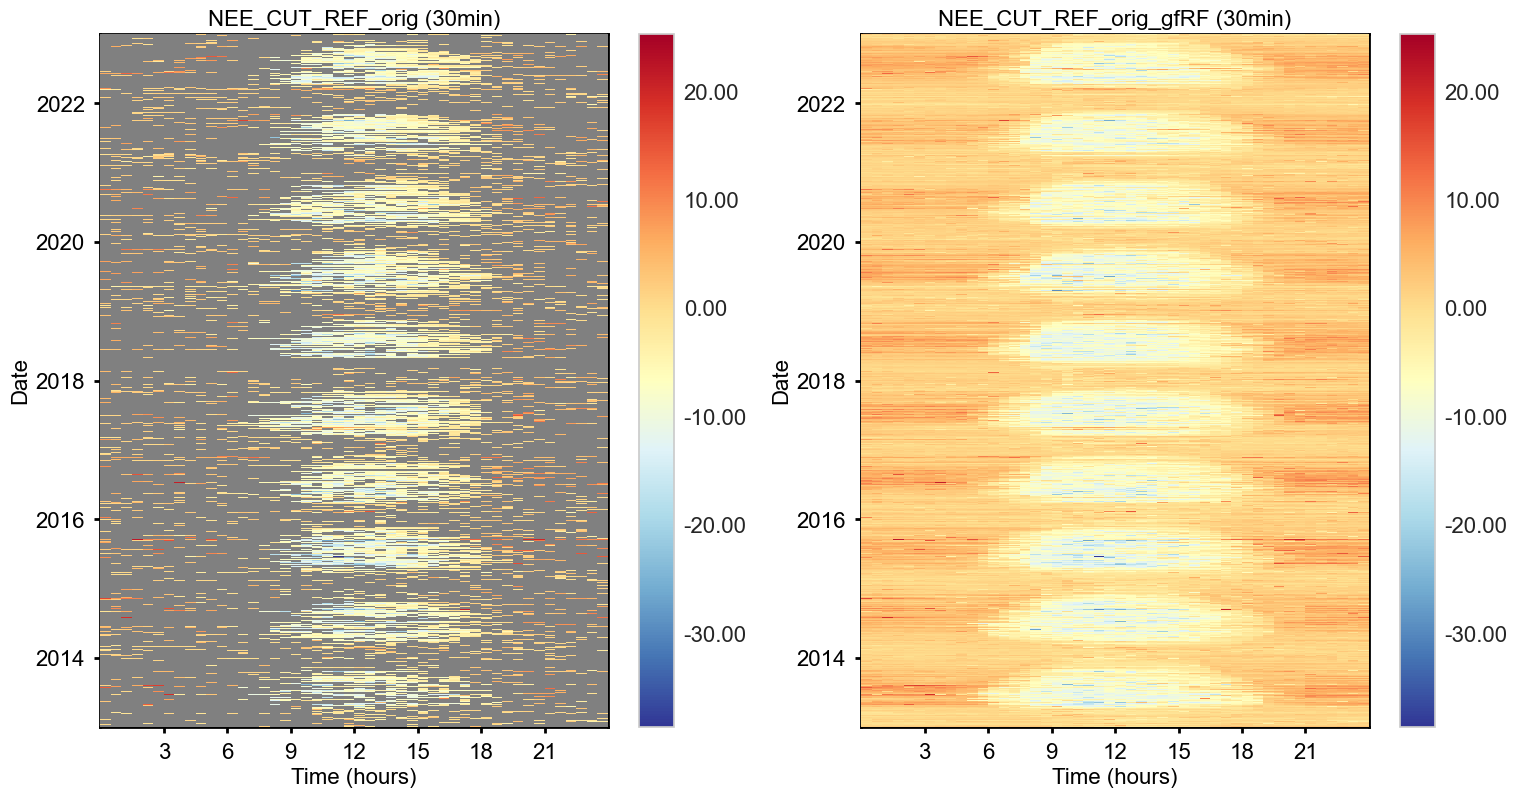

In [24]:
fig, axs = plt.subplots(ncols=2, figsize=(18, 9))
HeatmapDateTime(series=df[TARGET_COL], ax=axs[0]).plot()
HeatmapDateTime(series=gf.gapfilling_df_[gf.gapfilled_.name], ax=axs[1]).plot()

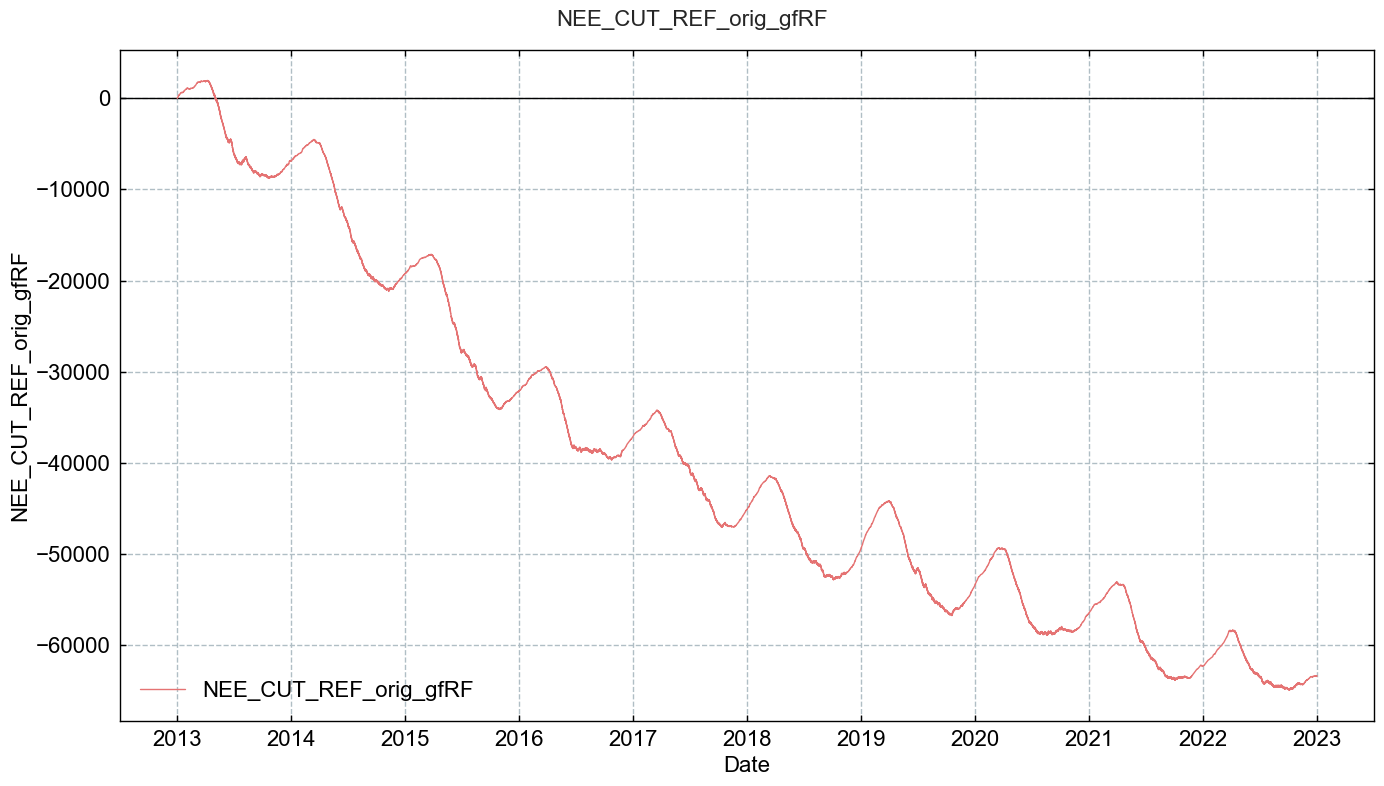

In [25]:
TimeSeries(series=gf.gapfilling_df_[gf.gapfilled_.name].cumsum()).plot()

</br>

# **End of notebook**
Congratulations, you reached the end of this notebook! Before you go let's store your finish time.

In [26]:
dt_string = datetime.now().strftime("%Y-%m-%d %H:%M:%S")
print(f"Finished. {dt_string}")

Finished. 2026-01-12 21:46:11
